In [ ]:
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.3 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from sklearn.preprocessing import LabelEncoder

from art.estimators.classification import PyTorchClassifier
from art.attacks.inference.model_inversion import MIFace

In [ ]:
!wget https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.tar.Z

--2026-03-03 09:37:51--  https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.tar.Z
Resolving www.cl.cam.ac.uk (www.cl.cam.ac.uk)... 128.232.0.20, 2a05:b400:110::80:14
Connecting to www.cl.cam.ac.uk (www.cl.cam.ac.uk)|128.232.0.20|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4075767 (3.9M) [application/x-compress]
Saving to: ‘att_faces.tar.Z’

att_faces.tar.Z     100%[===================>]   3.89M  4.77MB/s    in 0.8s    

2026-03-03 09:37:52 (4.77 MB/s) - ‘att_faces.tar.Z’ saved [4075767/4075767]



In [ ]:
!ls

att_faces.tar.Z  att_faces.zip	sample_data


In [ ]:
!ls -l

total 4432
-rw-r--r-- 1 root root 4530176 Jun 28  2005 att_faces.tar
-rw-r--r-- 1 root root       9 Mar  3 09:36 att_faces.zip
drwxr-xr-x 1 root root    4096 Jan 16 14:24 sample_data


In [ ]:
!tar -xvf att_faces.tar

orl_faces/
orl_faces/README
orl_faces/s1/
orl_faces/s1/6.pgm
orl_faces/s1/7.pgm
orl_faces/s1/8.pgm
orl_faces/s1/9.pgm
orl_faces/s1/10.pgm
orl_faces/s1/1.pgm
orl_faces/s1/2.pgm
orl_faces/s1/3.pgm
orl_faces/s1/4.pgm
orl_faces/s1/5.pgm
orl_faces/s2/
orl_faces/s2/6.pgm
orl_faces/s2/7.pgm
orl_faces/s2/8.pgm
orl_faces/s2/9.pgm
orl_faces/s2/10.pgm
orl_faces/s2/1.pgm
orl_faces/s2/2.pgm
orl_faces/s2/3.pgm
orl_faces/s2/4.pgm
orl_faces/s2/5.pgm
orl_faces/s3/
orl_faces/s3/6.pgm
orl_faces/s3/7.pgm
orl_faces/s3/8.pgm
orl_faces/s3/9.pgm
orl_faces/s3/10.pgm
orl_faces/s3/1.pgm
orl_faces/s3/2.pgm
orl_faces/s3/3.pgm
orl_faces/s3/4.pgm
orl_faces/s3/5.pgm
orl_faces/s4/
orl_faces/s4/6.pgm
orl_faces/s4/7.pgm
orl_faces/s4/8.pgm
orl_faces/s4/9.pgm
orl_faces/s4/10.pgm
orl_faces/s4/1.pgm
orl_faces/s4/2.pgm
orl_faces/s4/3.pgm
orl_faces/s4/4.pgm
orl_faces/s4/5.pgm
orl_faces/s5/
orl_faces/s5/6.pgm
orl_faces/s5/7.pgm
orl_faces/s5/8.pgm
orl_faces/s5/9.pgm
orl_faces/s5/10.pgm
orl_faces/s5/1.pgm
orl_faces/s5/2.pgm
orl_

In [ ]:
!ls

att_faces.tar  att_faces.zip  orl_faces  sample_data


In [ ]:
!ls orl_faces

README	s11  s14  s17  s2   s22  s25  s28  s30	s33  s36  s39  s5  s8
s1	s12  s15  s18  s20  s23  s26  s29  s31	s34  s37  s4   s6  s9
s10	s13  s16  s19  s21  s24  s27  s3   s32	s35  s38  s40  s7


In [ ]:
class FaceCNN(nn.Module):
    def __init__(self):
        super(FaceCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        # After 1 pooling:
        # 92x112 → 46x56

        self.fc1 = nn.Linear(64 * 46 * 56, 128)
        self.fc2 = nn.Linear(128, 40)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
import os
import numpy as np
from torchvision import transforms
from PIL import Image

def load_att_faces(path):
    images = []
    labels = []

    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((92, 112)),
        transforms.ToTensor()
    ])

    label_id = 0

    for person in sorted(os.listdir(path)):
        person_path = os.path.join(path, person)

        if os.path.isdir(person_path):
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = Image.open(img_path)
                img = transform(img)
                images.append(img.numpy())
                labels.append(label_id)

            label_id += 1

    return np.array(images), np.array(labels)

In [ ]:
x_data, y_data = load_att_faces("orl_faces")
print(x_data.shape)

(400, 1, 92, 112)


In [ ]:
print("Data shape:", x_data.shape)
print("Labels shape:", y_data.shape)
print("Number of classes:", len(np.unique(y_data)))

Data shape: (400, 1, 92, 112)
Labels shape: (400,)
Number of classes: 40


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FaceCNN(nn.Module):
    def __init__(self):
        super(FaceCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64 * 46 * 56, 128)
        self.fc2 = nn.Linear(128, 40)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FaceCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_tensor = torch.tensor(x_train).float().to(device)
train_labels = torch.tensor(y_train).long().to(device)

epochs = 30

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(train_tensor)
    loss = criterion(outputs, train_labels)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 5, Loss: 3.5203
Epoch 10, Loss: 2.5207
Epoch 15, Loss: 0.9240
Epoch 20, Loss: 0.1383
Epoch 25, Loss: 0.0135
Epoch 30, Loss: 0.0024


In [ ]:
model.eval()

test_tensor = torch.tensor(x_test).float().to(device)
test_labels = torch.tensor(y_test).long().to(device)

with torch.no_grad():
    outputs = model(test_tensor)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == test_labels).float().mean()

print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.9624999761581421


In [ ]:
from art.estimators.classification import PyTorchClassifier

classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(1, 92, 112),
    nb_classes=40,
    device_type='gpu' if torch.cuda.is_available() else 'cpu'
)

In [ ]:
from art.attacks.inference.model_inversion import MIFace

attack = MIFace(classifier, max_iter=100, threshold=0.01)

In [ ]:
from art.attacks.inference.model_inversion import MIFace

attack = MIFace(classifier)

target_class = 0

# Create one-hot encoded target
y_target = np.zeros((1, 40))
y_target[0, target_class] = 1

# Run inversion
reconstructed = attack.infer(x=None, y=y_target)

Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

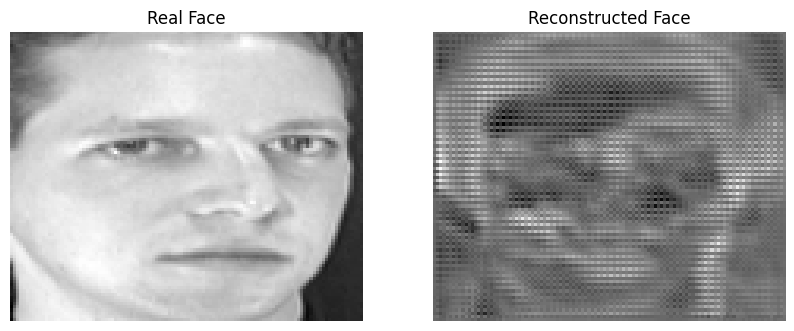

In [ ]:
real_sample = x_train[y_train == target_class][0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(real_sample[0], cmap='gray')
plt.title("Real Face")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed[0][0], cmap='gray')
plt.title("Reconstructed Face")
plt.axis("off")

plt.show()

Starting


Model inversion:   0%|          | 0/1 [00:00<?, ?it/s]

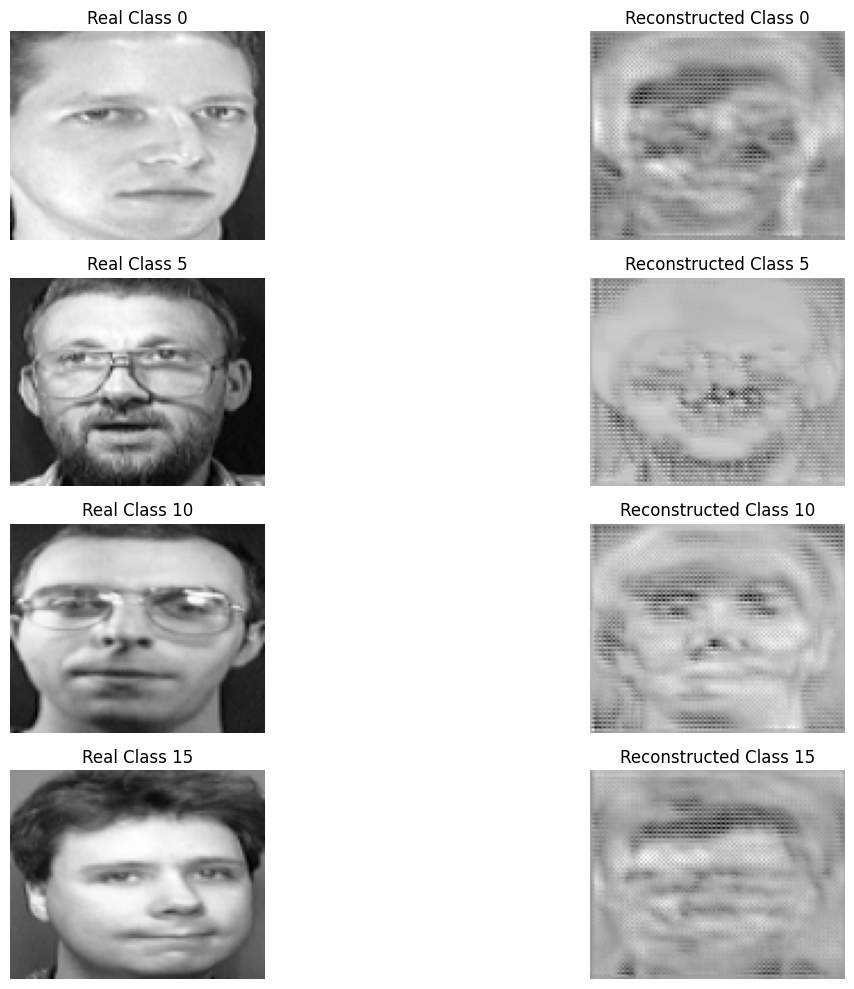

In [ ]:
# 1. Setup targets
targets = [0, 5, 10, 15]
y_targets = np.eye(40)[targets]

# 2. Optimized Attack Config
attack = MIFace(classifier, max_iter=150, threshold=0.001, batch_size=len(targets))

# 3. Run Batch Inversion (Faster)
print("Starting")
reconstructed_all = attack.infer(x=None, y=y_targets)

# 4. Visualize
plt.figure(figsize=(15, 10))
for i, target_class in enumerate(targets):
    real_sample = x_train[y_train == target_class][0]

    # Real Image
    plt.subplot(len(targets), 2, 2*i + 1)
    plt.imshow(real_sample[0], cmap='gray')
    plt.title(f"Real Class {target_class}")
    plt.axis("off")

    # Reconstructed Image
    plt.subplot(len(targets), 2, 2*i + 2)
    plt.imshow(reconstructed_all[i][0], cmap='gray')
    plt.title(f"Reconstructed Class {target_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Results and Observations
1. Reconstruction Quality

The MI-Face algorithm successfully reconstructs representative facial structures for the selected target classes. While the generated images are not photorealistic, they clearly capture the global facial geometry such as head shape, position of eyes, nose region, and overall contour. The reconstructions resemble “class prototypes” rather than exact copies of individual images.

2. Privacy Implications

This experiment demonstrates that trained neural network models can leak sensitive information about their training data. Even without direct access to the original face images, an adversary can reconstruct recognizable facial structures using only the model’s output predictions. This represents a serious privacy vulnerability in biometric systems.

3. Effect of Model Accuracy and Overfitting

The success of the inversion attack is strongly influenced by the model’s training accuracy. Since the custom FaceCNN achieves high training performance, it likely memorizes discriminative features of each individual. Higher memorization generally makes inversion attacks more effective because the model embeds detailed class-specific representations in its weights.

4. Comparison with Class Notebook

In comparison to the MNIST model inversion example discussed in class, reconstructing faces is more challenging due to higher input dimensionality and more complex grayscale structures. However, the MI-Face algorithm effectively navigates the feature space of the trained custom CNN and successfully generates representative face templates for each identity.

5. Security Insight

This experiment highlights the importance of incorporating privacy-preserving learning techniques such as differential privacy or regularization strategies to mitigate information leakage from trained models.